In [1]:
# usamos los datos de titanic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importamos scikit learn

from sklearn.preprocessing import OneHotEncoder #Preprocesador One Hot Encoding
from sklearn.model_selection import train_test_split #Split
from sklearn.model_selection import cross_val_score #cross validation
from sklearn.model_selection import GridSearchCV #grid search
from sklearn.ensemble import RandomForestClassifier #RF clasificador
from sklearn.compose import ColumnTransformer #Aplicador preprocesamiento a columnas
from sklearn.metrics import accuracy_score #metricas de error
from sklearn.svm import SVC #
from scipy.stats import chi2_contingency #Para colinearidad entre categoricas
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
import multiprocessing

# Importamos la librerria para regex

import re

In [2]:
titanic = pd.read_csv("Data/titanic.csv")
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
#Cuantifico null

titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
#Vemos los tipos de null

#Imputamos cabina

print('Data types of missing values')
for col in titanic.columns[titanic.isnull().any()]:
    print(col, titanic[col][titanic[col].isnull()].values[0])

Data types of missing values
Age nan
Cabin nan
Embarked nan


<AxesSubplot:title={'center':'Missing values in percentage'}, ylabel='percentage'>

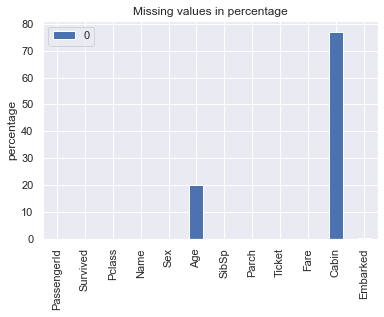

In [5]:
#Porcentaje de null

sns.set()

miss_vals = pd.DataFrame(titanic.isnull().sum() / len(titanic) * 100)
miss_vals
miss_vals.plot(kind='bar',title='Missing values in percentage',ylabel='percentage')


In [6]:
#Imputamos datos a Age, Cabin y embarked con scikit learn
#usamos from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='mean')
titanic['Age'] = impute.fit_transform(titanic[['Age']])
titanic['Age'].describe()


count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [7]:
impute = SimpleImputer(strategy='most_frequent')
titanic['Cabin'] = impute.fit_transform(titanic[['Cabin']])

titanic['Cabin'].value_counts()

B96 B98        691
G6               4
C23 C25 C27      4
F2               3
D                3
              ... 
A20              1
C91              1
D10 D12          1
D56              1
E77              1
Name: Cabin, Length: 147, dtype: int64

In [8]:
#Imputamos Embarked

impute = SimpleImputer(strategy='most_frequent')
titanic['Embarked'] = impute.fit_transform(titanic[['Embarked']])

titanic['Embarked'].value_counts()



S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [9]:
#Creo una variable para viajar solo o en familia

titanic['family'] = titanic['SibSp'] + titanic['Parch']
titanic.loc[titanic['family'] > 0, 'viaja_solo'] = 0
titanic.loc[titanic['family'] == 0, 'viaja_solo'] = 1

In [10]:
#Probamos el one hot encoding

#Convierto las variables object en categoricas

titanic['Sex'] = titanic['Sex'].astype('category')
titanic['Embarked'] = titanic['Embarked'].astype('category')
titanic['viaja_solo'] = titanic['viaja_solo'].astype('category')

#Borro las columnas que no voy a usar

titanic.drop(['PassengerId', 'Name','Ticket','SibSp','Parch','family', 'Cabin'], axis=1, inplace=True)

titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   Fare        891 non-null    float64 
 5   Embarked    891 non-null    category
 6   viaja_solo  891 non-null    category
dtypes: category(3), float64(2), int64(2)
memory usage: 30.9 KB


In [11]:
# Listo todas las columnas categoricas y numericas

cat_cols = titanic.select_dtypes(include=['category']).columns.to_list()
num_cols = titanic.select_dtypes(include=['int64','float64']).columns.to_list()

titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   Fare        891 non-null    float64 
 5   Embarked    891 non-null    category
 6   viaja_solo  891 non-null    category
dtypes: category(3), float64(2), int64(2)
memory usage: 30.9 KB


In [12]:
preprocess = ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'),cat_cols)], remainder='passthrough')

In [13]:
transform = np.array(preprocess.fit_transform(titanic), dtype = np.str)



In [14]:
encoded_cat = preprocess.named_transformers_['onehot'].get_feature_names(cat_cols)

labels = np.concatenate([encoded_cat,num_cols])
labels

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'viaja_solo_0.0', 'viaja_solo_1.0', 'Survived', 'Pclass', 'Age',
       'Fare'], dtype=object)

In [15]:
pd.DataFrame(transform, columns= labels)

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,viaja_solo_0.0,viaja_solo_1.0,Survived,Pclass,Age,Fare
0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,22.0,7.25
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,38.0,71.2833
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,26.0,7.925
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,35.0,53.1
4,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,35.0,8.05
...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,27.0,13.0
887,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,19.0,30.0
888,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,29.69911764705882,23.45
889,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,26.0,30.0
